In [3]:
requirements = """pandas>=2.0.0
numpy>=1.24.0
matplotlib>=3.7.0
seaborn>=0.12.0
plotly>5.15.0
ydata-profiling>=4.5.0
"""
with open("requirements.txt", "w") as f:
    f.write(requirements)

In [4]:
%pip install -r requirements.txt

In [5]:
#install dataset from uciml repository
%pip install -U ucimlrepo

In [6]:
import pandas as pd
import numpy as np
from ucimlrepo import fetch_ucirepo,list_available_datasets
list_available_datasets()

-------------------------------------
The following datasets are available:
-------------------------------------
Dataset Name                                                                            ID    
------------                                                                            --    
Abalone                                                                                 1     
Adult                                                                                   2     
Annealing                                                                               3     
Audiology (Standardized)                                                                8     
Auto MPG                                                                                9     
Automobile                                                                              10    
Balance Scale                                                                           12    
Balloons                       

In [7]:
heart_disease = fetch_ucirepo(name='Heart Disease')
print(heart_disease)
df = pd.concat([heart_disease.data.targets,heart_disease.data.features],axis=1)

{'data': {'ids': None, 'features':      age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0     63    1   1       145   233    1        2      150      0      2.3   
1     67    1   4       160   286    0        2      108      1      1.5   
2     67    1   4       120   229    0        2      129      1      2.6   
3     37    1   3       130   250    0        0      187      0      3.5   
4     41    0   2       130   204    0        2      172      0      1.4   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
298   45    1   1       110   264    0        0      132      0      1.2   
299   68    1   4       144   193    1        0      141      0      3.4   
300   57    1   4       130   131    0        0      115      1      1.2   
301   57    0   2       130   236    0        2      174      0      0.0   
302   38    1   3       138   175    0        0      173      0      0.0   

     slope   ca  thal  
0        3  0.0   6.0  
1   

In [8]:
df.shape

(303, 14)

In [9]:
df.head()

,num,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,2,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,1,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,0,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,0,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


In [10]:
import pandas as pd
from ydata_profiling import ProfileReport

df = pd.concat([heart_disease.data.features, heart_disease.data.targets], axis=1)

# Generate the EDA report
profile = ProfileReport(df, title="Heart Disease EDA Report")
profile.to_file("heart_disease_report.html")
print("EDA report 'heart_disease_report.html' generated successfully!")

/tmp/ipykernel_42511/1983419806.py:2: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 14/14 [00:00<00:00, 135.45it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

EDA report 'heart_disease_report.html' generated successfully!


In [11]:
df.to_csv("heart_disease.csv", index=False)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


In [13]:
df.describe()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


In [14]:
df["sex"].value_counts()

,count
sex,
1,206
0,97


In [15]:
df['num'].value_counts()



,count
num,
0,164
1,55
2,36
3,35
4,13


In [16]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [17]:
age_bins = [29, 40, 50, 60, 70, 80]
age_labels = ['30-39', '40-49', '50-59', '60-69', '70-79']
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels, right=False)
df['ca'] = df.groupby('num')['ca'].transform(lambda x: x.fillna(x.median()))
df['thal'] = df.groupby('num')['thal'].transform(lambda x: x.fillna(x.mode()[0]))

In [18]:
df['target'] = (df['num']>0).astype(int)

In [19]:
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,age_group,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0,60-69,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2,60-69,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1,60-69,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0,30-39,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0,40-49,0


In [20]:
df['target'].value_counts(normalize=True)

,proportion
target,
0,0.541254
1,0.458746


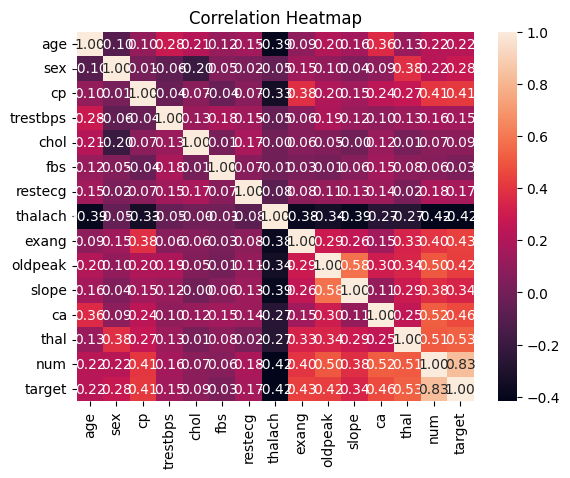

<Figure size 2000x1400 with 0 Axes>

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

df = df.drop(columns=['age_group'])
sns.heatmap(df.corr(), annot=True, fmt=".2f")
plt.title('Correlation Heatmap')
plt.figure(figsize=(20, 14))
plt.show()

In [22]:
for col in df.columns:
    values = df[col]
    uniq = pd.unique(values)
    if values.dtype == 'object' or len(uniq) < 10:
        print(f"{col} is categorical")
    else:
        print(f"{col} is numerical")

age is numerical
sex is categorical
cp is categorical
trestbps is numerical
chol is numerical
fbs is categorical
restecg is categorical
thalach is numerical
exang is categorical
oldpeak is numerical
slope is categorical
ca is categorical
thal is categorical
num is categorical
target is categorical


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', 'passthrough', cat_cols)])

X = df[num_cols + cat_cols]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalach', 'oldpeak']),
                                                 ('cat', 'passthrough',
                                                  ['sex', 'cp', 'fbs',
                                                   'restecg', 'exang', 'slope',
                                                   'ca', 'thal'])])),
                ('classifier', LogisticRegression())])

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]))

              precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61

ROC AUC Score: 0.9288793103448275
